In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from collections import namedtuple
from math import sin, cos, sqrt, asin as arcsin
#from scipy.spatial.transform import Rotation
from matplotlib.patches import Polygon
from itertools import product

In [2]:
#Кортеж для многогранников
Polyhedron = namedtuple(typename='Polyhedron', field_names=('vertices', 'faces'))

In [3]:
def trimetric(α, β):
    #матрица поворота вокруг осей х и у
    α = np.deg2rad(α)
    β = np.deg2rad(β)
    return np.array([
        [cos(α), 0, sin(α), 0],
        [sin(α)*sin(β), cos(β), -sin(β)*cos(α), 0],
        [-sin(α)*cos(β), sin(β), cos(α)*cos(β), 0],
        [0, 0, 0, 1]
    ])

In [4]:
#Возвращает повороты для диметрической проекции на плоскость Оху
def dimetric(f_z, signs=(1, 1)):
    s_1, s_2 = np.sign(signs)
    α = np.rad2deg(arcsin(s_1 * f_z / sqrt(2 - f_z*f_z)))
    β = np.rad2deg(arcsin(s_2 * f_z / sqrt(2)))
    return trimetric(α, β)

In [5]:
#Возвращает повороты для изометрической проекции на плоскость Оху
def isometric(signs=(1, 1)):
    s_1, s_2 = np.sign(signs)
    α = s_1*45
    β = s_1 * np.rad2deg(arcsin(1/sqrt(3)))
    return trimetric(α, β)

In [6]:
#ориентированная площадь одного из треугольников грани куба
def signed_square(vertices, face):
    p1, p2, p3 = vertices[face][0:3, (0, 1, 3)]
    return np.linalg.det(np.column_stack((p1, p2, p3)))

In [7]:
#единичрный куб, вершины заданы в однородных координатах
cube = Polyhedron(
    vertices = np.array([
        [0, 0, 0, 1], #0
        [0, 1, 0, 1], #1
        [1, 1, 0, 1], #2
        [1, 0, 0, 1], #3
        [0, 0, 1, 1], #4
        [0, 1, 1, 1], #5
        [1, 1, 1, 1], #6
        [1, 0, 1, 1], #7
    ]),
    faces = [
        [0, 4, 5, 1], #0
        [0, 3, 7, 4], #1
        [3, 2, 6, 7], #2
        [2, 1, 5, 6], #3
        [0, 1, 2, 3], #4
        [6, 5, 4, 7], #5
    ]
)
#Квадраст со стороной = 1, лежащий на плоскости Охz, одна его вершина в нуле
unit_square = Polyhedron(
    vertices = np.array([
        [0, 0, 0, 1],
        [1, 0, 0, 1],
        [1, 0, 1, 1],
        [0, 0, 1, 1],
    ]),
    faces = [[0, 1, 2, 3]]
)

cube_centered = Polyhedron(
    vertices = cube.vertices-0.5*np.array([1, 1, 1, 0]),
    faces = np.copy(cube.faces)
)

In [8]:
XYZ_vectors = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1], 
])

In [9]:
cube.vertices @ trimetric(45, 30).T

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00],
       [ 0.00000000e+00,  8.66025404e-01,  5.00000000e-01,
         1.00000000e+00],
       [ 7.07106781e-01,  1.21957879e+00, -1.12372436e-01,
         1.00000000e+00],
       [ 7.07106781e-01,  3.53553391e-01, -6.12372436e-01,
         1.00000000e+00],
       [ 7.07106781e-01, -3.53553391e-01,  6.12372436e-01,
         1.00000000e+00],
       [ 7.07106781e-01,  5.12472013e-01,  1.11237244e+00,
         1.00000000e+00],
       [ 1.41421356e+00,  8.66025404e-01,  5.00000000e-01,
         1.00000000e+00],
       [ 1.41421356e+00, -5.55111512e-17,  1.11022302e-16,
         1.00000000e+00]])

In [10]:
X, Y, Z, W = cube.vertices.T
X

array([0, 0, 1, 1, 0, 0, 1, 1])

In [11]:
def draw_trimetric_cube(α, β):
    fig01 = plt. figure(num=1, figsize=(5, 5), dpi=200)
    ax01 = fig01.add_subplot(1, 1, 1)
    ax01.set_xlim(left=-2, right=2)
    ax01.set_ylim(bottom=-2, top=2)
    ax01.set_aspect('equal')

    #α = 45 
    #β = 30
    ex,  ey,  ez,  ew = XYZ_vectors @ trimetric(α, β). T

    ax01.axline(xy1=(0, 0), xy2=ex[[0, 1]], color='red', lw=0.5, zorder = -15 )#, zorder = -15
    ax01.axline(xy1=(0, 0), xy2=ey[[0, 1]], color='green', lw=0.5, zorder = -15 )#, zorder = -15
    ax01.axline(xy1=(0, 0), xy2=ez[[0, 1]], color='blue', lw=0.5, zorder = -15 )#, zorder = -15
    
    transformed_vertices = cube.vertices @ trimetric(α, β).T

    for face in cube.faces:
        if signed_square(transformed_vertices, face) <= 0:
            continue
        ss = signed_square(transformed_vertices, face)
        polygon = Polygon(
             xy=transformed_vertices[face][:, 0:2],
             closed=True,
             fill=False,
             facecolor = 'gray',
             edgecolor='black' if ss > 0 else 'gray',
             zorder = 10 if ss > 0 else -10
        )
        ax01.add_patch(polygon)
    


<function __main__.draw_trimetric_cube(α, β)>

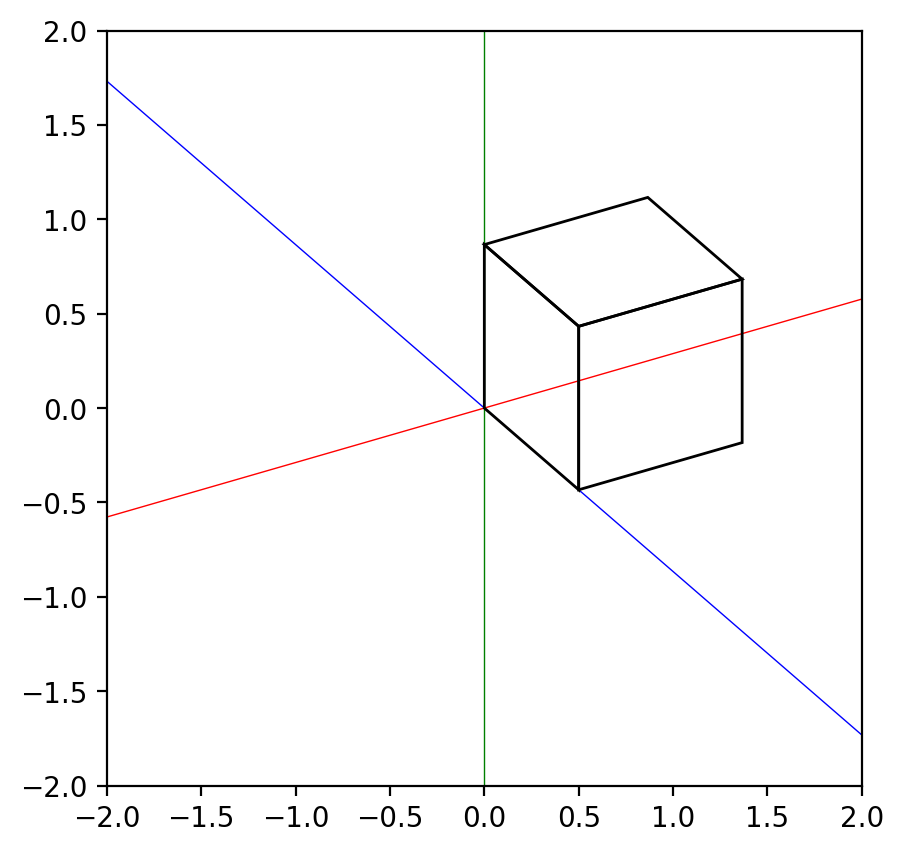

In [12]:
widgets.interact(draw_trimetric_cube, α=(-30, 90, 1), β=(-30, 90, 1))

In [13]:
def draw_cube_iso(cx=0, cy=0, cz=0):
    fig02 = plt. figure(num=2, figsize=(5, 5), dpi=200)
    ax02 = fig02.add_subplot(1, 1, 1)
    ax02.set_xlim(left=-1, right=14)
    ax02.set_ylim(bottom=-7, top=7)
    ax02.set_aspect('equal')

    ex,  ey,  ez,  ew = XYZ_vectors @ isometric(signs=(1, 1)).T

    ax02.axline(xy1=(0, 0), xy2=ex[[0, 1]], color='red', lw=0.5,  zorder = -15 )#,
    ax02.axline(xy1=(0, 0), xy2=ey[[0, 1]], color='green', lw=0.5, zorder = -15 )#, zorder = -15
    ax02.axline(xy1=(0, 0), xy2=ez[[0, 1]], color='blue', lw=0.5, zorder = -15 )#, zorder = -15

    for i, j in product(range(0, 9), repeat =2):
        tile_vertices = (unit_square.vertices + np.array([i, 0, j, 0])) @ isometric(signs=(1, 1)).T
        for face in unit_square.faces:
                    polygon = Polygon(
                         xy=tile_vertices[face][:, 0:2],
                         closed=True,
                         fill = True,
                         facecolor = 'red' if (i+j)%2 == 0 else 'blue',
                         edgecolor='white' 
                    )
                    ax02.add_patch(polygon)

    transformed_vertices = (cube.vertices + np.array([cx, cy, cz, 0])) @ isometric(signs=(1, 1)).T
    for face in cube.faces:
            if signed_square(transformed_vertices, face) <= 0:
                continue
            ss = signed_square(transformed_vertices, face)
            polygon = Polygon(
                 xy=transformed_vertices[face][:, 0:2],
                 closed=True,
                 fill=True if ss > 0 else False,
                 facecolor = 'gray',
                 edgecolor='black' if ss > 0 else 'None',
                 zorder = 10 if ss > 0 else -10
            )
            ax02.add_patch(polygon)

<function __main__.draw_cube_iso(cx=0, cy=0, cz=0)>

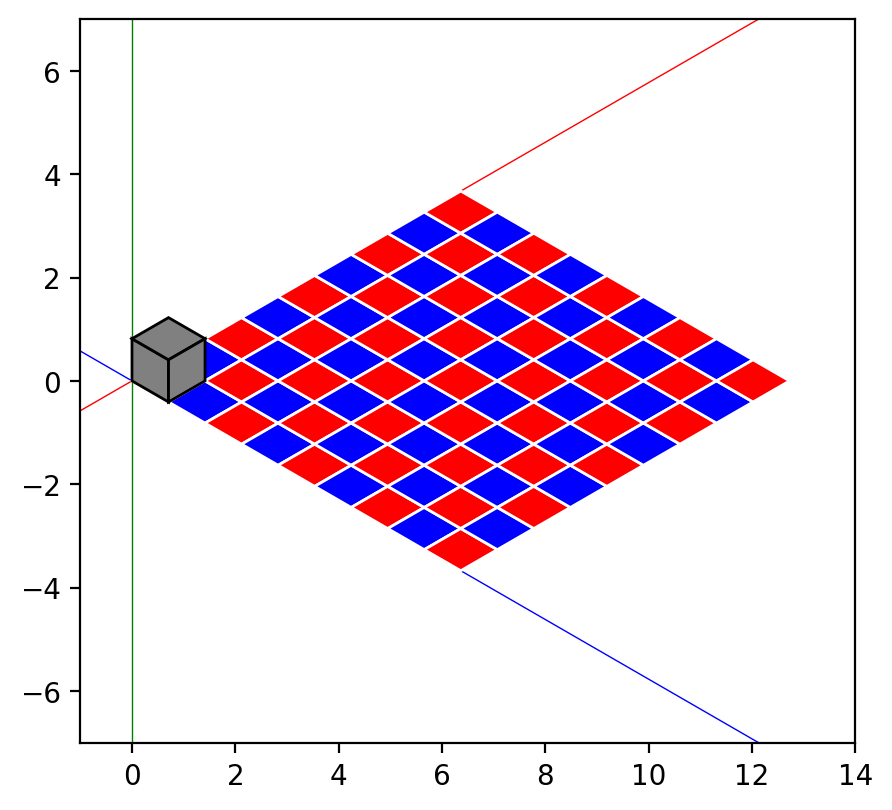

In [14]:
widgets.interact(draw_cube_iso, cx=(0, 10, 1), cy=(0, 10, 1), cz=(0, 10, 1))